# Lección 10 - Afinación del Vision Transformer

En esta lección veremos cómo usar el concepto de transferencia de aprendizaje (visto en la lección 7) para realizar la afinación del Vision Transformer (ViT).

Y haremos esto para el set de datos que hemos usado en las lecciones anteriores (imágenes cerebrales).

## 1. El problema a resolver

Resolveremos el mismo problema de la lección 7 pero usando transferencia de aprendizaje (afinación):

> Entrenar, validar y poner a prueba un ViT afinado para clasificar imágenes de resonancia magnética del cerebro en tres diferentes categorías dependiendo del tipo de tumor, **usando un enfoque de transferencia de aprendizaje (afinación)**

## 2. Estrategia de afinación

Como ViT es un modelo extremadamente grande (más de 87 millones de parámetros) realizaremos la afinación usando el primer enfoque visto en la lección 7:

1. Congelar las capas extractoras de características
2. Modificar y entrenar únicamente la capa de salida

<img src="https://drive.google.com/uc?export=view&id=1hwl_8vMtWjovTX8Nhcafg9JSpMEekC-q" width="750">

Así que en esta lección veremos cómo implementar este enfoque con ayuda de librerías de HuggingFace.

## 3. Librerías a usar y configuración inicial

Aunque el enfoque es similar al visto en la lección 7, en este caso usaremos librerías de HuggingFace (y no PyTorch) que facilitarán la implementación.

Así que usaremos:

- Transformers (v4.48.3): para acceder al preprocesador y al modelo pre-entrenado
- Datasets (v3.3.2): para crear los sets de entrenamiento, validación y prueba en el formato aceptado por la librería Transformers
- Evaluate (v0.4.3): para definir la métrica de desempeño con la cual evaluaremos el modelo

Instalemos estas librerías:

Comencemos importando las librerías requeridas:

In [1]:
!pip install transformers==4.57.3
!pip install datasets==4.0.0
!pip install evaluate==0.4.6

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 21.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


Y deshabilitemos la opción de almacenar los resultados de entrenamiento en *Weights and Biases* (en la nube):

In [2]:
import os
os.environ["WANDB_DISABLED"] = "true"

Y ahora sí importemos todas las librerías necesarias:

In [3]:
# Acceder al dataset en Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Afinación
from datasets import load_dataset, DatasetDict
from transformers import ViTImageProcessor, ViTForImageClassification, TrainingArguments, Trainer, pipeline
import evaluate
import numpy as np
import torch

# Lectura y visualización de datos
from PIL import Image
import matplotlib.pyplot as plt
import random

# Evaluación del desempeño del modelo
from sklearn.metrics import classification_report

Mounted at /content/drive


Perfecto. Ahora veamos cómo preparar el set de datos.

## 4. Dataset de HuggingFace

Para poder alimentar el modelo pre-entrenado durante la afinación debemos cargar nuestros datos en el formato de Dataset de HuggingFace.

Comencemos descargando el set de datos y descomprimiéndolo en la carpeta "brain_dataset":

In [4]:
# Copiar archivo a la carpeta "content"
!cp "/content/drive/MyDrive/MAESTRIA VIRTUAL CIENCIA DE DATOS/MAESTRIA_DEEP_LEARNING/LABORATORIOS/NOTEBOOK_5_TRANSFORMERS/LLM_BASICO_VISION_TRANSFORMER/leccion_6.zip" "/content/"

# Y descomprimir
!unzip -q /content/leccion_6.zip -d /content/brain_dataset

Y ahora creamos el dataset de HuggingFace:

In [5]:
# Dataset completo
ds = load_dataset("imagefolder", data_dir="/content/brain_dataset")

# Partición 1: 80% entrenamiento, 20% resto
train_resto_split = ds["train"].train_test_split(test_size=0.2, seed=42)

# Partición 2: el 20% (resto) se divide en 2 mitades
resto_split = train_resto_split["test"].train_test_split(test_size=0.5, seed=42)

# Combinar lo anterior en un dataset usando DatasetDict
dataset = DatasetDict({
    "train": train_resto_split["train"],
    "validation": resto_split["train"],
    "test": resto_split["test"]
})

# Imprimir información del set de datos en pantalla
print(dataset)

Resolving data files:   0%|          | 0/6056 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4844
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 606
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 606
    })
})


Veamos por ejemplo un dato de entrenamiento:

In [6]:
dato = dataset['validation'][10]
print(dato)
img = dato['image']

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=512x512 at 0x7FC439E371D0>, 'label': 2}


Y veamos en detalle las características de la imagen:

In [7]:
print(f"Tamaño de cada imagen: {img.size}")
print(f"Modalidad: {img.mode}")
print(f"Niveles pixeles: {img.getextrema()}")

Tamaño de cada imagen: (512, 512)
Modalidad: RGB
Niveles pixeles: ((0, 255), (0, 255), (0, 255))


Así que es necesario realizar el pre-procesamiento de las imágenes antes de llevarlas al modelo. Para ello usaremos más adelante ViTImageProcessor.

Antes de continuar, veamos las etiquetas obtenidas automáticamente al momento de crear el dataset:

In [8]:
dataset['train'].features['label']

ClassLabel(names=['brain_glioma', 'brain_menin', 'brain_tumor'])

Y para poder acceder a las etiquetas (ids) o a las categorías (labels) crearemos dos diccionarios de equivalencias que resultarán útiles más adelante:

In [9]:
labels = dataset['train'].features['label'].names
id2label_dic={str(i): c for i, c in enumerate(labels)}
label2id_dic={c: str(i) for i, c in enumerate(labels)}

print(id2label_dic)
print(label2id_dic)

{'0': 'brain_glioma', '1': 'brain_menin', '2': 'brain_tumor'}
{'brain_glioma': '0', 'brain_menin': '1', 'brain_tumor': '2'}


## 5. Afinación del ViT

Con todo esto ya estamos listos para realizar la afinación del modelo.

Esta afinación se divide en 7 pasos:

1. Pre-procesamiento de las imágenes
2. Crear un "data-collator" de HuggingFace, que permitirá presentar las imágenes al modelo durante la afinación
3. Crear una función para calcular la métrica de desempeño
4. Cargar el modelo pre-entrenado
5. Definir los parámetros del entrenamiento
6. Afinar el modelo
7. Evaluar el modelo afinado

Vaemos cada uno de estos pasos en detalle.

### 5.1. Pre-procesamiento de las imágenes

Como lo vimos en la lección anterior, antes de presentar cualquier imagen al ViT debemos realizar el pre-procesamiento. Para ello usaremos "VitImageProcessor".

Anteriormente vimos que este procesador:

- Escala las imágenes a 224x224 con 3 canales
- Estandariza los pixeles en cada canal

Así que crearemos la función "transformar_lote" que tomará un lote de imágenes del Dataset creado anteriormente y retornará las imágenes transformadas con sus respectivas etiquetas:

In [10]:
# Cargar el procesador
RUTA_MODELO = 'google/vit-base-patch16-224'
procesador = ViTImageProcessor.from_pretrained(RUTA_MODELO)

def transformar_lote(batch):
    # Imágenes del lote en formato RGB
    images = [x.convert("RGB") for x in batch['image']]

    # Pre-procesamiento
    inputs = procesador(images, return_tensors='pt')

    # Añadir etiquetas (categorías)
    inputs['label'] = batch['label']

    return inputs

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Y lo usamos para transformar todas las imágenes del dataset (entrenamiento + validación + prueba):

In [11]:
ds_transf = dataset.with_transform(transformar_lote)
ds_transf

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4844
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 606
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 606
    })
})

No se observan cambios aparentes. Así que extraigamos un dato de entrenamiento y veamos las características de la imagen transformada:

In [12]:
img, lbl = ds_transf['train'][100]['pixel_values'], ds_transf['train'][100]['label']

print(f"Imagen transformada: ")
print(f"\tTamaño: {img.shape}")
print(f"\tMínimos/máximos pixeles: {img.min()}/{img.max()}")
print(f"Etiqueta: {lbl}")

Imagen transformada: 
	Tamaño: torch.Size([3, 224, 224])
	Mínimos/máximos pixeles: -1.0/0.7490196228027344
Etiqueta: 0


### 5.2. "Data collator"

Este elemento es el equivalente del dataloader en PyTorch y permite presentar lotes de datos al modelo:

In [13]:
def data_collator(batch):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.tensor([x['label'] for x in batch])
    }

Y veamos un ejemplo de los datos que retorna este "data collator":

In [14]:
dato = data_collator([ds_transf['train'][5]])
print(f"Contenido del dato: {dato.keys()}")
print(f"Campo 'pixel_values': {dato['pixel_values'].shape}")
print(f"Campo 'labels': {dato['labels']}")

Contenido del dato: dict_keys(['pixel_values', 'labels'])
Campo 'pixel_values': torch.Size([1, 3, 224, 224])
Campo 'labels': tensor([2])


### 5.3. Métrica de evaluación

Acá definimos la métrica que se mostrará en pantalla en cada iteración de la afinación y que nos permitirá ver el desempeño del modelo.

Como lo hemos venido viendo en lecciones anteriores, usaremos el puntaje F1 y para esta implementación haremos uso de la librería "Evaluate" importada anteriormente:

In [15]:
metrica = evaluate.load("f1")

def calcular_metrica(p):
    preds = np.argmax(p.predictions, axis=1)
    refs = p.label_ids

    return metrica.compute(
        predictions=preds,
        references=refs,
        average="weighted" # <--- Clave, calcular F1 ponderado (global) para las 3 clases
    )

### 5.4. Cargar el modelo pre-entrenado

Este paso es muy similar al usado en la lección anterior cuando cargamos el modelo desde HuggingFace. Sin embargo, en este caso usaremos algunos argumentos adicionales para garantizar que la cabecera de salida (clasificador) contiene las categorías en las que nos interesa clasificar nuestras imágenes:

In [16]:
modelo = ViTForImageClassification.from_pretrained(
    RUTA_MODELO,
    num_labels=len(labels), # 3
    id2label=id2label_dic,
    label2id=label2id_dic,
    ignore_mismatched_sizes=True # <--- Ignorar la cabecera de clasificación original
)
modelo

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

Y acá observamos que el bloque de salida ("classifier") contiene precisamente 3 neuronas ("out_features=3") que coincide con el número de categorías en nuestro set de datos.

Es decir, lo que acabamos de hacer ha sido simplemente cargar el modelo pre-entrenado y hemos personalizado la capa "fully connected".

Sin embargo, en este punto **TODOS** los parámetros son entrenables y lo que nos interesa es congelar el bloque extractor de características y "descongelar" el bloque clasificador:

In [17]:
# Congelar TODOS los parámetros del modelo
for param in modelo.parameters():
    param.requires_grad = False

# Y ahora descongelar únicamente la capa "classifier"
for param in modelo.classifier.parameters():
    param.requires_grad = True

Realicemos el conteo de parámetros para ver cuántos son entrenables y cuántos son no entrenables:

In [18]:
def conteo_parametros(model):
    entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
    no_entrenables = sum(p.numel() for p in model.parameters() if not p.requires_grad)

    print(f"Parámetros entrenables:     {entrenables:,}")
    print(f"Parámetros no entrenables:  {no_entrenables:,}")
    print(f"Total parámetros:           {entrenables + no_entrenables:,}")

conteo_parametros(modelo)

Parámetros entrenables:     2,307
Parámetros no entrenables:  85,798,656
Total parámetros:           85,800,963


Si queremos afinar la totalidad del modelo (extractor de características + clasificador) pues simplemente descongelamos todos los parámetros:



```
for param in modelo.parameters():
    param.requires_grad = False
```

Sin embargo, en esta lección no usaremos este enfoque dado que el modelo tiene más de 80 millones de parámetros.

### 5.5. Definir los parámetros del entrenamiento

En este caso usaremos "TrainingArguments" de HuggingFace para definir la forma como queremos afinar el modelo:

In [19]:
training_args = TrainingArguments(
    output_dir="./vit-afinacion",
    eval_strategy="epoch",            # Evaluar al final de cada época
    save_strategy="epoch",            # Almacenar al final de cada época
    learning_rate=1e-4,
    num_train_epochs=5,
    per_device_train_batch_size=32,   # Tamaño del lote "pequeño" para evitar problemas de RAM
    load_best_model_at_end=True,      # Cargar el mejor modelo al final del entrenamiento
    fp16=True,                        # Reducir número de bits (16 bits) para agilizar entrenamiento
    remove_unused_columns=False,      # Evita eliminar columnas no usadas por el modelo (importante para datasets con transformaciones)
    logging_steps=10,                 # Reportar pérdida de entrenamiento cada 10 lotes
    logging_strategy="steps",         # Para que funcione la línea anterior
)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


### 5.6. Afinación

Y en este punto lo único que nos resta es afinar el modelo, para lo cual usaremos el módulo "Trainer" de HuggingFace.

Comencemos definiendo una instancia de este módulo:

In [20]:
trainer = Trainer(
    model=modelo, # Modelo a entrenar (pre-entrenado)
    args=training_args, # Parámetros de entrenamiento
    data_collator=data_collator, # El data collator a usar
    compute_metrics=calcular_metrica, # La métrica que usaremos para medir el desempeño
    train_dataset=ds_transf["train"], # Set de entrenamiento
    eval_dataset=ds_transf["validation"], # Set de validación
    processing_class=procesador, # La forma como pre-procesaremos cada imagen
)

Y ahora usamos el método "train()" para afinar el modelo.

Algo útil de este método es que no es necesario definir explícitamente el dispositivo (GPU o CPU), el método busca automáticamente la GPU y entrena sobre este dispositivo (y si no existe entrena sobre la CPU):

In [21]:
train_results = trainer.train() # Entrenar y guardar resultados
trainer.save_model() # Guardar modelo entrenado en output_dir
trainer.log_metrics("train", train_results.metrics) # Registrar pérdida y exactitud
trainer.save_metrics("train", train_results.metrics) # Guardar pérdida y exactitud en archivos .json
trainer.save_state() # Para reanudar el entrenamiento en caso de interrupciones

Epoch,Training Loss,Validation Loss,F1
1,0.682400,0.676625,0.774226
2,0.516400,0.562349,0.811038
3,0.520900,0.511311,0.836510
4,0.458200,0.487520,0.849968
5,0.414900,0.480729,0.848472


***** train metrics *****
  epoch                    =          5.0
  total_flos               = 1747974017GF
  train_loss               =        0.579
  train_runtime            =   0:05:34.19
  train_samples_per_second =       72.473
  train_steps_per_second   =        2.274


Vemos que a pesar de que estamos afinando tan sólo la cabecera de clasificación, y de que hemos reducido la precisión a 16 bits, el tiempo de entrenamiento para tan sólo 5 iteraciones es de aproximadamente 4 min.

En este punto la variable "modelo" ya contiene el mejor modelo (pues usamos el argumento "load_best_model_at_end=True").

Sin embargo, si queremos reutilizar posteriormente el modelo estará almacenado en la carpeta "vit-afinacion":

- "model.safetensors": los parámetros del modelo afinado
- "config.json": la configuración del modelo (3 etiquetas, id2label, etc.)

En un momento veremos como cargar este modelo pre-entrenado desde el disco. Por ahora veamos las curvas de desempeño:

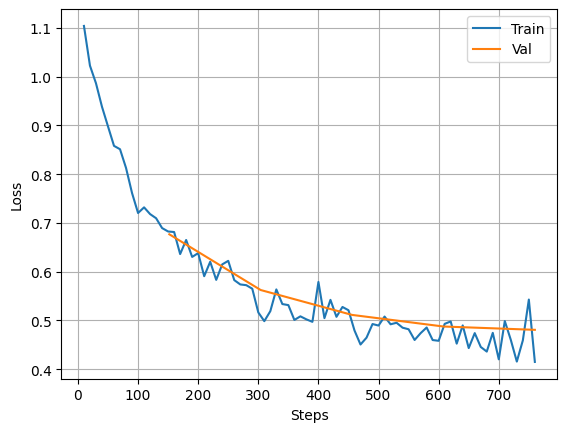

In [22]:
# Extraer las pérdidas (almacenadas en "trainer")
historia = trainer.state.log_history

# Separar pérdidas de entrenamiento y validación
train_loss = [log["loss"] for log in historia if "loss" in log]
train_steps = [log["step"] for log in historia if "loss" in log]

val_loss = [log["eval_loss"] for log in historia if "eval_loss" in log]
val_steps = [log["step"] for log in historia if "eval_loss" in log]

# Graficar
plt.plot(train_steps, train_loss, label='Train')
plt.plot(val_steps, val_loss, label='Val')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True);

Vemos que la afinación se podría extender unas cuantas iteraciones ("epochs") más.

Sin embargo, supondremos que en este punto ya estamos satisfechos con el modelo. Así que simplemente nos queda evaluar el desempeño del modelo con datos nuevos (el set de prueba).

## 6. Prueba del modelo

Comencemos cargando el modelo afinado directamente desde el disco:

In [23]:
# Cargar modelo afinado

# Ruta donde fue almacenado el modelo afinado
output_dir = "./vit-afinacion"

# Carga del modelo
modelo = ViTForImageClassification.from_pretrained(output_dir)
print(modelo)

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

¡Es así de simple! Vemos que el modelo tiene precisamente 3 neuronas de salida.

A continuación crearemos la función "clasificar" (similar a la usada en la lección 7) que nos permitirá obtener las etiquetas predichas y reales a partir de un set de datos:

In [24]:
modelo.config.label2id

{'brain_glioma': '0', 'brain_menin': '1', 'brain_tumor': '2'}

In [25]:
def clasificar(ruta_modelo, ds):
    # Crear pipeline de HuggingFace
    pipe = pipeline(
        "image-classification",
        model=ruta_modelo,
        device=0 if torch.cuda.is_available() else -1
    )

    # Extraer imágenes del set de prueba
    imgs_test = [img for img in ds["test"]["image"]]

    # Inferencia con la pipeline
    resultados = pipe(imgs_test, batch_size=16)

    # Extraer IDs predichos
    y_pred = [int(pipe.model.config.label2id[res[0]['label']]) for res in resultados]

    # Extraer IDs reales (directamente del set de datos)
    y_true = ds["test"]["label"]

    return np.array(y_pred), np.array(y_true)


**💡💡Nota importante:💡💡**

Para que la "pipeline" pueda cargar correctamente el modelo entrenado debemos garantizar que la carpeta "ruta_modelo" contiene estos archivos:

```
ruta_modelo/
├── config.json
├── preprocessor_config.json
├── model.safetensors
```

Y ahora sí generamos las predicciones sobre el set de prueba y obtenemos el reporte de clasificación:

In [26]:
y_pred, y_true = clasificar('./vit-afinacion', dataset)

print(classification_report(y_true, y_pred, target_names=dataset['train'].features['label'].names))

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


              precision    recall  f1-score   support

brain_glioma       0.84      0.82      0.83       215
 brain_menin       0.77      0.76      0.77       188
 brain_tumor       0.84      0.87      0.86       203

    accuracy                           0.82       606
   macro avg       0.82      0.82      0.82       606
weighted avg       0.82      0.82      0.82       606



Al comparar el desempeño de este modelo con el obtenido en el enfoque 1 de la lección 7 (Red Convolucional afinando sólo la capa de salida) vemos que el segundo tiene un F1-score global mayor (0.94 vs. 0.86).

Esto no quiere decir que el afinar una Red Convolucional siempre será mejor que afinar un ViT y el resultado que acabamos de obtener sólo es válido para este problema en particular.

Y ahora escogemos aleatoriamente tres imágenes de prueba, las clasificamos y mostramos el resultado:

Device set to use cuda:0


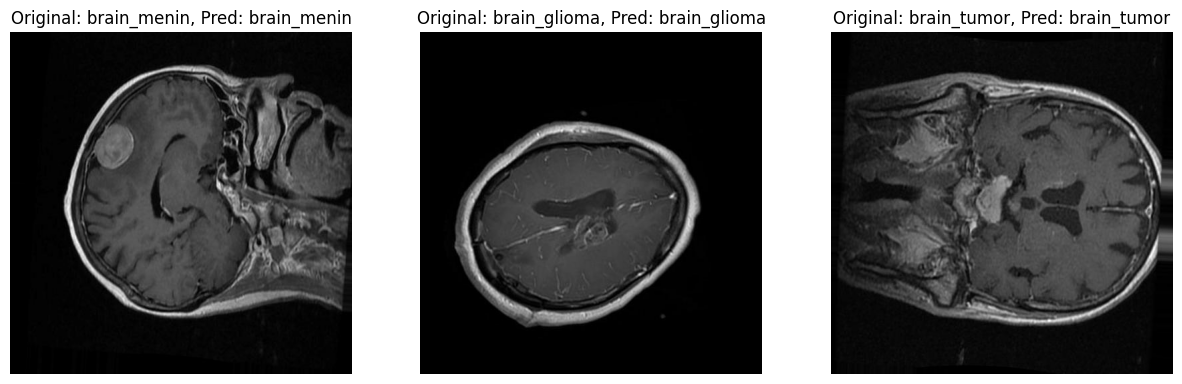

In [27]:
# Inicializar pipeline
pipe = pipeline(
    "image-classification",
    model="./vit-afinacion",
    device=0 if torch.cuda.is_available() else -1
)

# Seleccionar 3 índices aleatorios del set de prueba
test_ds = dataset["test"]
random_idx = random.sample(range(len(test_ds)), 3)

# Graficar
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, idx in enumerate(random_idx):
    # Extraer imagen original y etiqueta real
    image = test_ds[idx]["image"]
    label = test_ds[idx]["label"]
    cat = test_ds.features["label"].names[label]

    # Inferencia
    resultado = pipe(image)
    pred_label = resultado[0]['label']

    # Visualización
    axes[i].imshow(image)
    axes[i].set_title(f"Original: {cat}, Pred: {pred_label}")
    axes[i].axis("off")

## 7. ¿Cuándo usar y cuándo no usar transferencia de aprendizaje con ViT?

- ✅ Se sugiere comenzar afinando modelos de Redes Convolucionales (más pequeños, procesamiento más rápido)
- ✅ Y si el desempeño de dichos modelos se estanca, y tenemos una gran cantidad de datos, podemos probar afinando un ViT para ver si resulta posible mejorar el desempeño
- ❌ ViT es un tipo de modelo generalmente mucho más grande que las Redes Convolucionales, así que para afinarlo necesitamos gran capacidad de cómputo y de RAM.

## 8. Ventajas y desventajas de la transferencia de aprendizaje con ViT

- 👍 Nos permite aprovechar un modelo pre-entrenado que ya es robusto y con menos imágenes y recursos computacionales podemos especializarlo en la clasificación de nuestro dataset.
- 👍 Generalmente la afinación de hiper-parámetros no es tan crítica como en el entrenamiento desde cero
- 👎 Se requieren buenas capacidades de cómputo y un tiempo prolongado de entrenamiento (mucho mayores en comparación con la afinación de una Red Convolucional)